In [1]:
#Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
#Loading Fashion-MNIST Dataset
from google.colab import drive
drive.mount('/content/drive')
train_df = pd.read_csv('/content/drive/MyDrive/ML_Task/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ML_Task/fashion-mnist_test.csv')
train_df.head()

Mounted at /content/drive


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#Dataset and Dataloading
class FashionMNISTDataset(Dataset):
    def __init__(self, dataframe, train=True):
        self.train = train

        if train:
            self.labels = dataframe.iloc[:, 0].values
            self.images = dataframe.iloc[:, 1:].values
        else:
            # if test file has 785 columns, remove first column
            if dataframe.shape[1] == 785:
                self.images = dataframe.iloc[:, 1:].values
            else:
                self.images = dataframe.values

        self.images = self.images.reshape(-1, 28, 28).astype("float32") / 255.0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx])

        if self.train:
            label = torch.tensor(self.labels[idx]).long()
            return image, label

        return image

In [4]:
#Training-validation split
full_dataset = FashionMNISTDataset(train_df, train=True)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [5]:
#model code
class FashionModel(nn.Module):
    def __init__(self):
        super(FashionModel, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 16)

        self.branch1_fc1 = nn.Linear(16, 8)
        self.branch1_fc2 = nn.Linear(8, 8)

        self.branch2_fc1 = nn.Linear(16, 12)
        self.branch2_fc2 = nn.Linear(12, 8)

        self.output = nn.Linear(16, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)

        x = self.relu(self.fc1(x))

        b1_first = self.relu(self.branch1_fc1(x))
        b1_second = self.relu(self.branch1_fc2(b1_first))

        skip_output = b1_second + b1_first

        b2 = self.relu(self.branch2_fc1(x))
        b2 = self.relu(self.branch2_fc2(b2))

        combined = torch.cat((skip_output, b2), dim=1)

        out = self.output(combined)
        return out

In [6]:
#Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FashionModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
#Training and validation loop
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)


train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 20

for epoch in range(epochs):
    model.train()

    running_loss = 0
    running_acc = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)

    model.eval()

    val_loss_total = 0
    val_acc_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item()
            val_acc_total += calculate_accuracy(outputs, labels)

    val_loss = val_loss_total / len(val_loader)
    val_acc = val_acc_total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/20] Train Loss: 0.8061, Train Acc: 0.7165 | Val Loss: 0.5492, Val Acc: 0.8150
Epoch [2/20] Train Loss: 0.4909, Train Acc: 0.8286 | Val Loss: 0.4825, Val Acc: 0.8334
Epoch [3/20] Train Loss: 0.4457, Train Acc: 0.8442 | Val Loss: 0.4653, Val Acc: 0.8379
Epoch [4/20] Train Loss: 0.4223, Train Acc: 0.8514 | Val Loss: 0.4346, Val Acc: 0.8504
Epoch [5/20] Train Loss: 0.4091, Train Acc: 0.8565 | Val Loss: 0.4222, Val Acc: 0.8539
Epoch [6/20] Train Loss: 0.3951, Train Acc: 0.8621 | Val Loss: 0.4371, Val Acc: 0.8486
Epoch [7/20] Train Loss: 0.3846, Train Acc: 0.8649 | Val Loss: 0.4027, Val Acc: 0.8590
Epoch [8/20] Train Loss: 0.3763, Train Acc: 0.8678 | Val Loss: 0.3958, Val Acc: 0.8588
Epoch [9/20] Train Loss: 0.3697, Train Acc: 0.8685 | Val Loss: 0.3987, Val Acc: 0.8604
Epoch [10/20] Train Loss: 0.3610, Train Acc: 0.8712 | Val Loss: 0.3982, Val Acc: 0.8595
Epoch [11/20] Train Loss: 0.3556, Train Acc: 0.8729 | Val Loss: 0.3881, Val Acc: 0.8615
Epoch [12/20] Train Loss: 0.3501, Train A

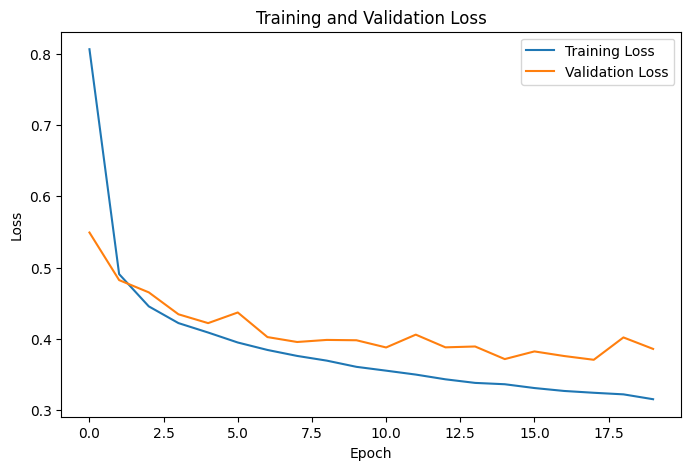

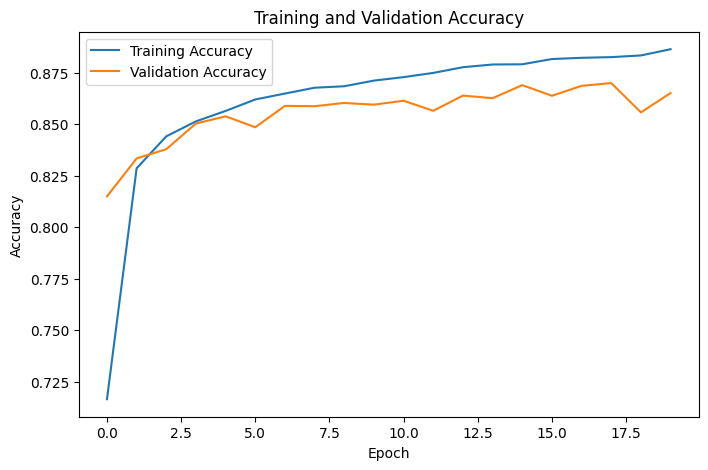

In [8]:
#Plot of losses and accuracies
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [9]:
#Saving weight using pickle
with open("model_weights.pkl", "wb") as file:
    pickle.dump(model.state_dict(), file)

In [10]:
#Generating submission.csv
test_dataset = FashionMNISTDataset(test_df, train=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,ImageId,Label
0,1,0
1,2,1
2,3,2
3,4,2
4,5,4
